In [1]:
print("Alhamdullilah")

Alhamdullilah


In [22]:
import pandas as pd

df = pd.read_csv("file:///home/bharathwaj/Code/ML/data/Country-data.csv")

print(df.head())
print(df.shape)
print(df.info())

               country  child_mort  exports  ...  life_expec  total_fer   gdpp
0          Afghanistan        90.2     10.0  ...        56.2       5.82    553
1              Albania        16.6     28.0  ...        76.3       1.65   4090
2              Algeria        27.3     38.4  ...        76.5       2.89   4460
3               Angola       119.0     62.3  ...        60.1       6.16   3530
4  Antigua and Barbuda        10.3     45.5  ...        76.8       2.13  12200

[5 rows x 10 columns]
(167, 10)
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null 

In [23]:
X = df.drop(columns=["country"])

Ask the first unsupervised learning question<br>
What Structure could reasonably exist in these observations?

#### Inspect the data

In [24]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


#### The first major unsupervised-learning problem: scale
If we calculate Euclidean distance directly for attributes with age & salary.<br>
salary will dominates the distance & K-Means fundamentally rely on distance.<br>

**Clustering algorithms that depend on distance are highly sensitive to feature scale.**

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
# Before doing this we first we need to understand what we're scaling and why

#### Look at distributions
Ask:
- Are the distributions symmetrics?
- Are there extreme values?
- Are some features heavily skewed?
- Are there potential outliers?
- Do some features appear to have very different scales?

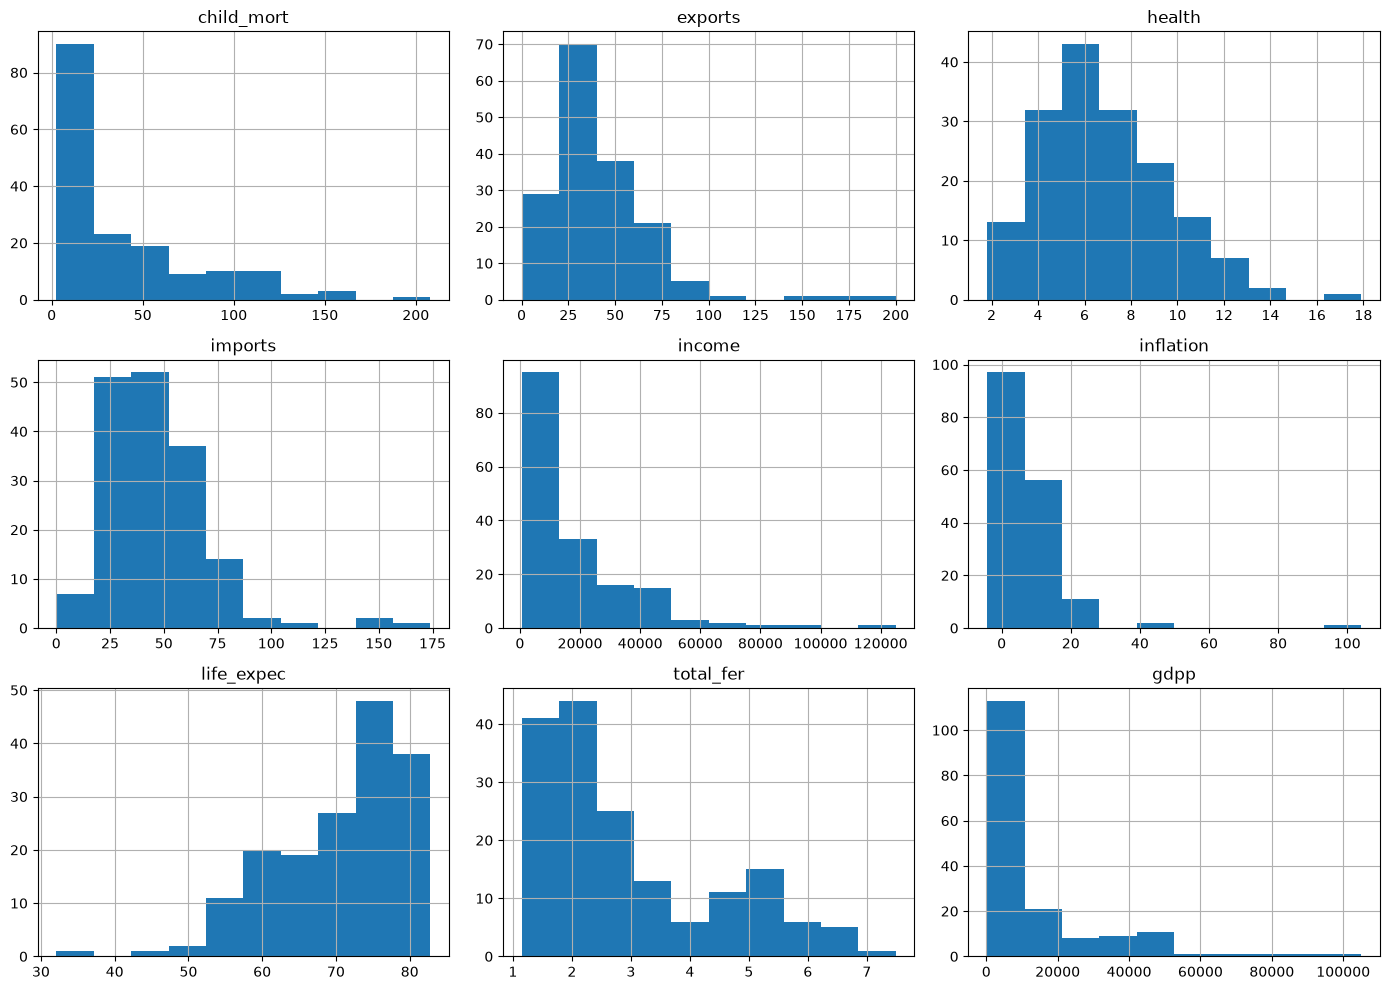

In [26]:
import matplotlib.pyplot as plt

df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

#### Examine correlations

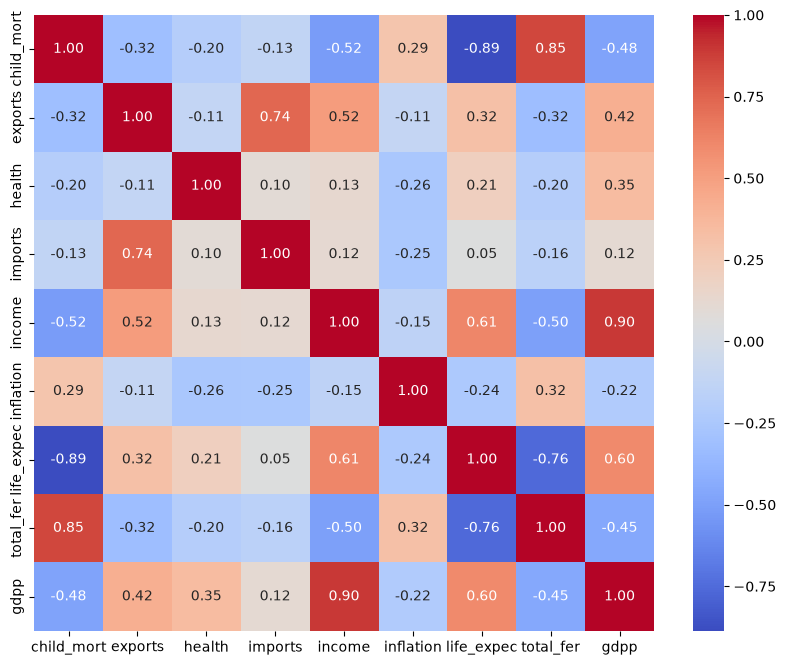

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop(columns=["country"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.show()

#### If several features contain similar information, are we effectively giving that underlysing factor extra importance?
for example:<br> income <-> gdpp - economic development <br>
This will become important later when we discuss **PCA**

#### Identity what we should NOT do

In [28]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3)
model.fit(X)
# Don't do like above code

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 9)",

We haven't established:
- Whether scaling is required
- Whether outliers matter
- How many clusters might exists
- Whether the features need transformation
- Whether clustering is appropriate

#### Our ML problem statement
We have: 
- 167 countries
- 9 numerical features
- 0 target variables

We want to discover: **Group of countries with similar socio-economic and health characteristics.**

In [29]:
print("Shape:")
print(df.shape)

print("\nColumns: ", df.columns.tolist())
print("\nData Types: ", df.dtypes)
print("\nMissing values: ", df.isnull().sum())
print("\nSummary Statistics: ", df.describe())
print("\nDuplicate rows: ", df.duplicated().sum())

Shape:
(167, 10)

Columns:  ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Data Types:  country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Missing values:  country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Summary Statistics:         child_mort     exports  ...   total_fer           gdpp
count  167.000000  167.000000  ...  167.000000     167.000000
mean    38.270060   41.108976  ...    2.947964   12964.155689
std     40.328931   27.412010  ...    1.513848   18328.704809
min      2.600000    0.109000  ...    1.150000     231.000000
25%      8.250000   23.800000  ...    1.795000    1330.000000
50%     19.300000   35.

In [30]:
# 1. Separate the identifier from the features

X = df.drop(columns=["country"])

print(X.shape)
print(X.head())

# 2. Check missing values
print(X.isnull().sum())

# 3. Look at feature range
# .T for transporse
X.agg(["min", "max"]).T

(167, 9)
   child_mort  exports  health  ...  life_expec  total_fer   gdpp
0        90.2     10.0    7.58  ...        56.2       5.82    553
1        16.6     28.0    6.55  ...        76.3       1.65   4090
2        27.3     38.4    4.17  ...        76.5       2.89   4460
3       119.0     62.3    2.85  ...        60.1       6.16   3530
4        10.3     45.5    6.03  ...        76.8       2.13  12200

[5 rows x 9 columns]
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,min,max
child_mort,2.6000,208.00
exports,0.1090,200.00
health,1.8100,17.90
imports,0.0659,174.00
income,609.0000,125000.00
inflation,-4.2100,104.00
life_expec,32.1000,82.80
total_fer,1.1500,7.49
gdpp,231.0000,105000.00


In [31]:
# 4. Standardization
# z = (x - mean)/std
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)
X_scaled_df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02
mean,-3.722904e-17,2.127373e-16,5.504579e-16,2.765585e-16,-7.977650e-17,-1.063687e-17,3.696311e-16,3.044803e-16,5.850277e-17
std,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00
min,-8.871383e-01,-1.500192e+00,-1.827827e+00,-1.939940e+00,-8.603259e-01,-1.137852e+00,-4.337186e+00,-1.191250e+00,-6.968005e-01
25%,-7.466190e-01,-6.333367e-01,-6.922106e-01,-6.914785e-01,-7.174558e-01,-5.666409e-01,-5.927576e-01,-7.639023e-01,-6.366596e-01
50%,-4.717981e-01,-2.235279e-01,-1.810007e-01,-1.487432e-01,-3.738080e-01,-2.269504e-01,2.869576e-01,-3.564309e-01,-4.544309e-01
75%,5.926666e-01,3.747198e-01,6.515412e-01,4.913530e-01,2.942370e-01,2.816364e-01,7.042584e-01,6.175252e-01,5.942100e-02
max,4.221297e+00,5.813835e+00,4.047436e+00,5.266181e+00,5.611542e+00,9.129718e+00,1.380962e+00,3.009349e+00,5.036507e+00


In [32]:
# 5. But here's an important nuance
# Standardization does not mean every feature becomes equally important in a business sense
# We just normalized using numerical scaling so that one doesn't dominate simply because it was measured in larger unit

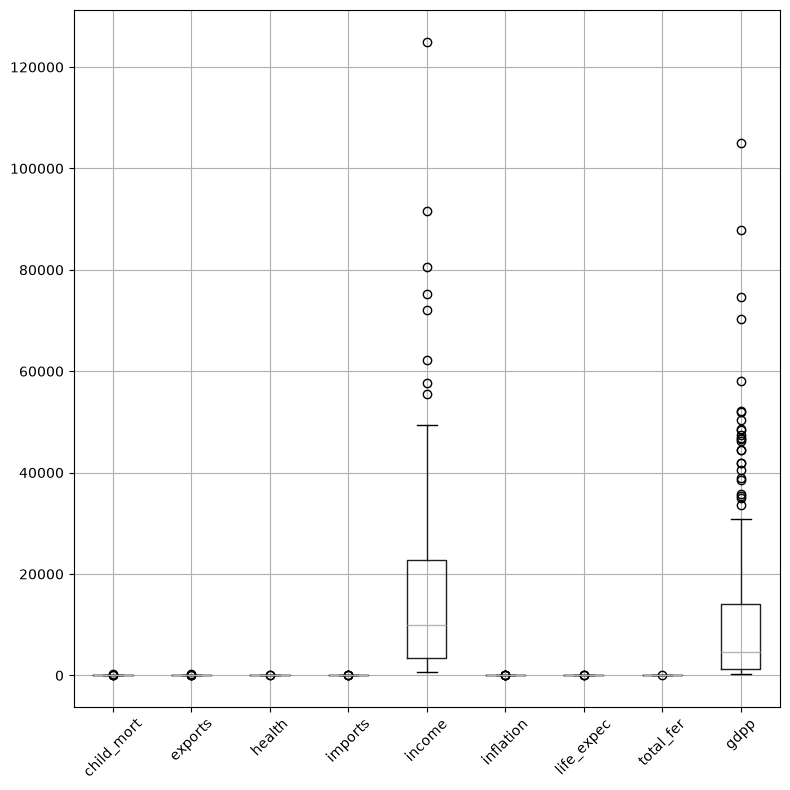

In [33]:
# 6. Inspect Outliers
# The dataset contains economic variables where extreme countries can exist
plt.figure(figsize=(8,8))
X.boxplot()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Look at skewness
X.skew().sort_values(ascending=False)

inflation     5.154049
exports       2.445824
income        2.231480
gdpp          2.218051
imports       1.905276
child_mort    1.450774
total_fer     0.967092
health        0.705746
life_expec   -0.970996
dtype: float64

In [35]:
# For heavily right-skewed positive variables, a common transformation is:
import numpy as np
X_log = X.copy()

for col in ["income", "gdpp"]:
    X_log[col] = np.log1p(X_log[col])

X_log.skew().sort_values(ascending=False)

# The distribution may become considerably less skewed. But don't automatically apply this to everything
# Applying log1p() for negative value attribute isn't right choice

inflation     5.154049
exports       2.445824
imports       1.905276
child_mort    1.450774
total_fer     0.967092
health        0.705746
gdpp          0.006548
income       -0.235823
life_expec   -0.970996
dtype: float64

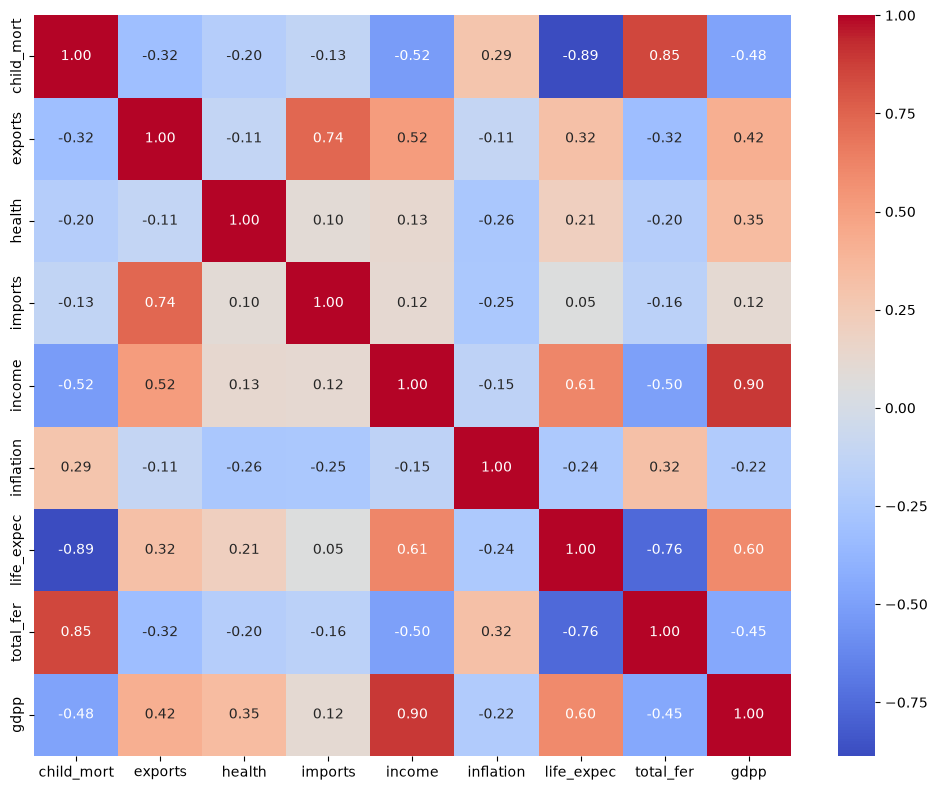

In [36]:
# Feature correlation
corr = X.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"    
)

plt.tight_layout()
plt.show()

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pipeline = Pipeline([
    ("scalar", StandardScaler()),
    ("kmeans", KMeans(n_clusters=3, random_state=42))
])

In [38]:
# Feature ranges
print(X.agg(["min", "max"]).T)

# Skewness
print(X.skew().sort_values(ascending=False))

# Correlation
print(X.corr().round(2))

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled,columns=X.columns)

print(X_scaled_df.describe().round(2))

                 min        max
child_mort    2.6000     208.00
exports       0.1090     200.00
health        1.8100      17.90
imports       0.0659     174.00
income      609.0000  125000.00
inflation    -4.2100     104.00
life_expec   32.1000      82.80
total_fer     1.1500       7.49
gdpp        231.0000  105000.00
inflation     5.154049
exports       2.445824
income        2.231480
gdpp          2.218051
imports       1.905276
child_mort    1.450774
total_fer     0.967092
health        0.705746
life_expec   -0.970996
dtype: float64
            child_mort  exports  health  ...  life_expec  total_fer  gdpp
child_mort        1.00    -0.32   -0.20  ...       -0.89       0.85 -0.48
exports          -0.32     1.00   -0.11  ...        0.32      -0.32  0.42
health           -0.20    -0.11    1.00  ...        0.21      -0.20  0.35
imports          -0.13     0.74    0.10  ...        0.05      -0.16  0.12
income           -0.52     0.52    0.13  ...        0.61      -0.50  0.90
inflation     

In [39]:
X_toy = np.array([
    [1,1],
    [1,2],
    [2,1],
    [8,8],
    [9,8],
    [8,9]
])
K = 2

In [40]:
# Step 1 - Initialize centroids
import numpy as np

def euclidean_distance(point, centroid):
    return np.sqrt(np.sum(point - centroid) ** 2)

point = np.array([2,1])
centroid = np.array([1,1])

print(euclidean_distance(point, centroid))

# Assign every point
def assign_clusters(X, centroids):
    assignments = []

    for point in X:
        distances = []

        for centroid in centroids:
            distance = euclidean_distance(point, centroid)
            distances.append(distance)

        closest_cluster = np.argmin(distances)

        assignments.append(closest_cluster)

    return np.array(assignments)

centroids = np.array([
    [1,1],
    [8,8]
])

assignments = assign_clusters(X_toy, centroid)

print(assignments)

1.0
[0 0 0 0 0 0]


In [41]:
# Calculate new centroids
def calculate_centroids(X, assignments, K):
    centroids = []

    for k in range(K):
        cluster_points = X[assignments == k]
        centroid = cluster_points.mean(axis=0)
        centroids.append(centroid)
    return np.array(centroids)

new_centroids = calculate_centroids(
    X_toy,
    assignments,
    K=2
)

print(new_centroids)

[[4.83333333 4.83333333]
 [       nan        nan]]


/tmp/ipykernel_9148/800368192.py:7: RuntimeWarning: Mean of empty slice
  centroid = cluster_points.mean(axis=0)
/media/bharathwaj/406A55226A55164E/anaconda3/envs/ml/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [42]:
def kmeans_from_scratch(X, K, max_iterations=100):
    # random initialization
    random_indices = np.random.choice(
        len(X),
        K,
        replace=False
    )

    centroids = X[random_indices]

    for iteration in range(max_iterations):
        # Step 1: Assign points
        assignments = assign_clusters(
            X,
            centroids
        )

        # Step 2: Calculate new centroids
        new_centroids = calculate_centroids(X, assignments, K)

        # Step 3: check convergence
        if np.allclose(centroids, new_centroids):
            print(f"Converged at iteration {iteration} ")
            break

        centroids = new_centroids

    return centroids, assignments

centroids, assignments = kmeans_from_scratch(
    X_toy,
    K=2
)

print("Centroid: ", centroids)

print("\nAssignments: ", assignments)

Converged at iteration 1 
Centroid:  [[1.33333333 1.33333333]
 [8.33333333 8.33333333]]

Assignments:  [0 0 0 1 1 1]


In [43]:
centroids, assignments = kmeans_from_scratch(
    X_scaled,
    K=2
)

result = df[["country"]].copy()
result["cluster"] = assignments
result.head()

Converged at iteration 14 


,country,cluster
0,Afghanistan,1
1,Albania,1
2,Algeria,1
3,Angola,0
4,Antigua and Barbuda,1


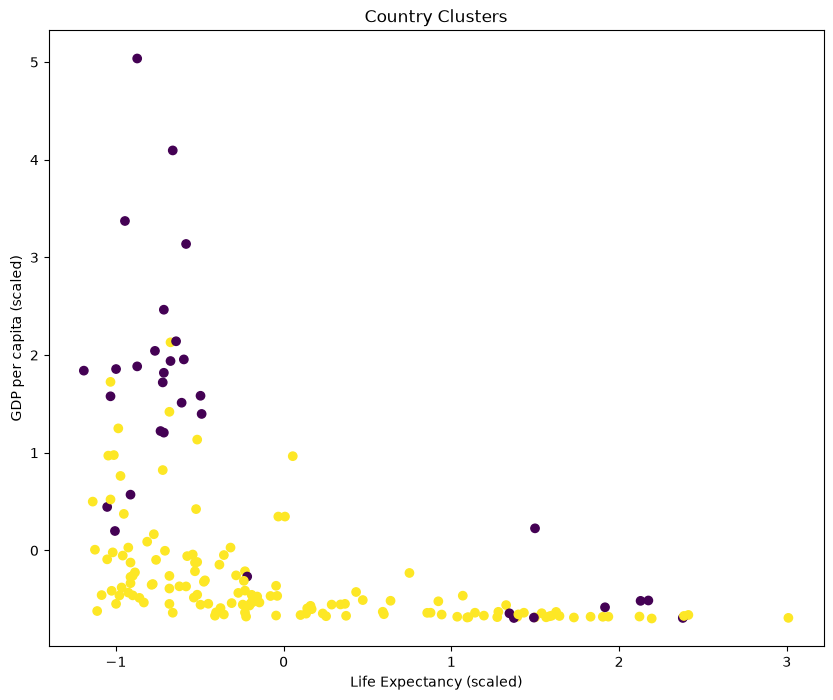

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    X_scaled[:, 7],  # life expectancy
    X_scaled[:, 8],  # gdpp
    c=assignments
)

plt.xlabel("Life Expectancy (scaled)")
plt.ylabel("GDP per capita (scaled)")
plt.title("Country Clusters")

plt.show()

In [45]:
# Sci-kit learn implementation
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = model.fit_predict(X_scaled)

print(labels)

print(model.cluster_centers_)
print(model.inertia_)

print(np.bincount(labels))

[1 2 2 1 2 2 2 0 0 2 2 0 2 2 2 0 2 1 2 2 2 1 2 0 2 1 1 2 1 0 2 1 1 2 2 2 1
 1 1 2 1 2 0 0 0 2 2 2 2 1 1 2 2 0 0 1 1 2 0 1 0 2 2 1 1 2 1 2 0 2 2 2 1 0
 0 0 2 0 2 2 1 1 0 2 1 2 2 1 1 2 2 0 2 1 1 2 2 1 0 1 2 2 2 2 2 2 1 2 1 2 0
 0 1 1 0 2 1 2 2 2 2 2 0 0 2 2 1 2 2 1 2 2 1 0 0 0 2 1 0 0 2 2 1 2 0 0 2 1
 2 1 1 2 2 2 2 1 2 0 0 0 2 2 2 2 2 1 1]
[[-0.82744866  0.64507985  0.72741122  0.19063895  1.48424268 -0.48492064
   1.07957853 -0.79187687  1.61599536]
 [ 1.36021776 -0.43753313 -0.15598401 -0.18920377 -0.68689408  0.40211078
  -1.28217981  1.36494385 -0.60424243]
 [-0.40645337 -0.03165259 -0.2244709   0.02416161 -0.25177041 -0.01716742
   0.25473362 -0.42434279 -0.35448141]]
831.4244352086876
[36 47 84]


#### The Elbow Method

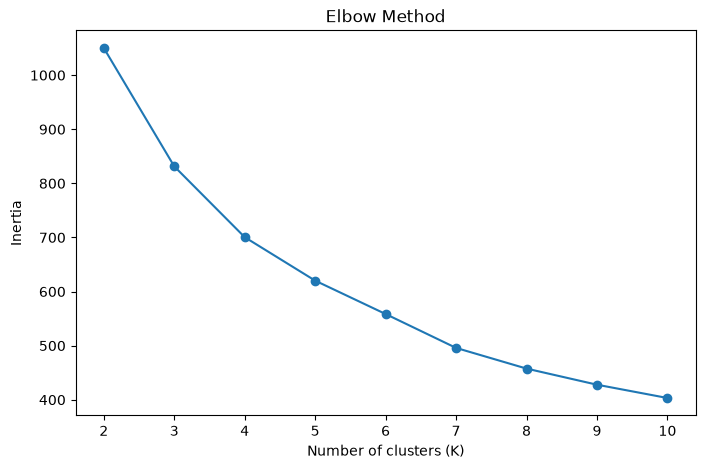

In [46]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []

K_values = range(2, 11)

for k in K_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    K_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

#### Silhouette Score

K=2
Silhouette=0.287
K=3
Silhouette=0.283
K=4
Silhouette=0.296
K=5
Silhouette=0.299
K=6
Silhouette=0.229
K=7
Silhouette=0.248
K=8
Silhouette=0.239
K=9
Silhouette=0.207
K=10
Silhouette=0.202


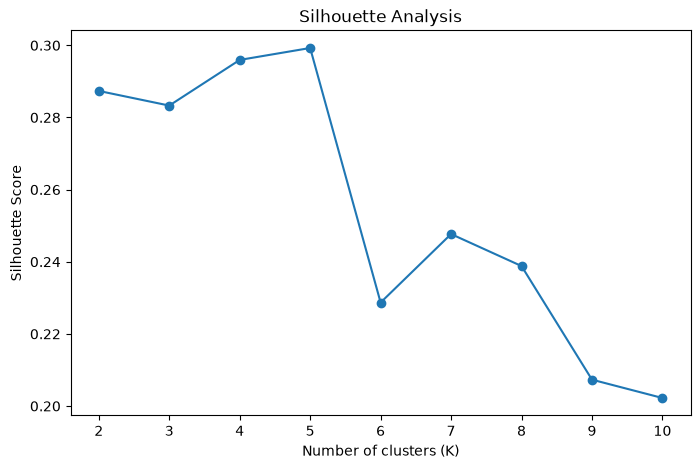

In [47]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_values = range(2, 11)

for k in K_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K={k}")
    print(f"Silhouette={score:.3f}")

plt.figure(figsize=(8,5))

plt.plot(
    K_values,
    silhouette_scores,
    marker = "o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [48]:
results = []

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia = model.inertia_

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette
    })

evaluation_df = pd.DataFrame(results)
print(evaluation_df)

    k      inertia  silhouette
0   2  1050.214558    0.287357
1   3   831.424435    0.283296
2   4   700.520537    0.295952
3   5   620.163371    0.299259
4   6   558.469660    0.228692
5   7   495.807946    0.247681
6   8   457.586148    0.238811
7   9   427.803672    0.207312
8  10   403.229613    0.202230


In [49]:
df_clustered = df.copy()

df_clustered["cluster"] = labels

cluster_summary= (
    df_clustered
    .groupby("cluster")
    .mean(numeric_only=True)
)
print(cluster_summary)

for cluster_id in sorted(df_clustered["cluster"].unique()):
    print(f"\nCluster {cluster_id}")

    print(
        df_clustered[
            df_clustered["cluster"] == cluster_id
        ]["country"].tolist()
    )

         child_mort     exports     health  ...  life_expec  total_fer          gdpp
cluster                                     ...                                     
0         32.914706   28.520265   5.227059  ...   69.967647   2.700000   4280.764706
1          4.313636   41.222727  10.491364  ...   80.940909   1.830000  46459.090909
2         18.068750   61.271875   6.037187  ...   73.340625   2.200625   8871.125000
3         86.390909   44.945455   5.125455  ...   63.190909   5.210000   3818.363636
4        130.000000   25.300000   5.070000  ...   60.500000   5.840000   2330.000000
5          4.133333  176.000000   6.793333  ...   81.433333   1.380000  57566.666667
6         12.807692   33.226923   8.222308  ...   75.565385   1.776154   9582.692308
7         11.050000   64.900000   3.000000  ...   77.083333   2.308333  36283.333333
8        107.614286   19.474286  11.430000  ...   54.028571   4.344286   1019.857143
9         94.144000   23.623600   5.715200  ...   58.840000   5.2

#### PCA

In [50]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

# Examine explained variance
# These value represent the fraction of total variance captured by each component.
pca_ratio = pca.explained_variance_ratio_
pca_ratio = list(pca_ratio)
total = 0
for x in pca_ratio:
    total += x
    print(f"{x:.4f}: {(total/1)*100:.4f}")

(167, 9)
0.4595: 45.9517
0.1718: 63.1334
0.1300: 76.1376
0.1105: 87.1908
0.0734: 94.5310
0.0248: 97.0152
0.0126: 98.2757
0.0098: 99.2569
0.0074: 100.0000


In [51]:
# Calculate cummulative variance
import numpy as np
cummulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(cummulative_variance)

[0.4595174  0.63133365 0.76137624 0.87190786 0.94530998 0.97015232
 0.98275663 0.99256944 1.        ]


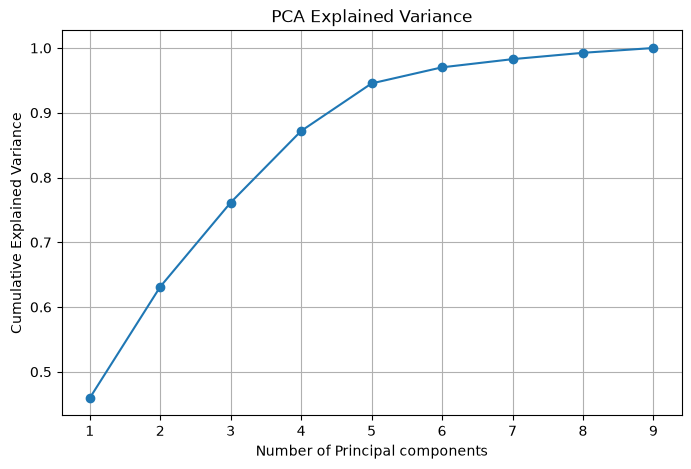

In [52]:
# Plot explained variance
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cummulative_variance)+1),
    cummulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.show()
# 4 Principal Components explain ~75% variance
# We could potentially represent the data using 4 dimensions instead og 9 while retaining mcuh of its variation.

(167, 2)


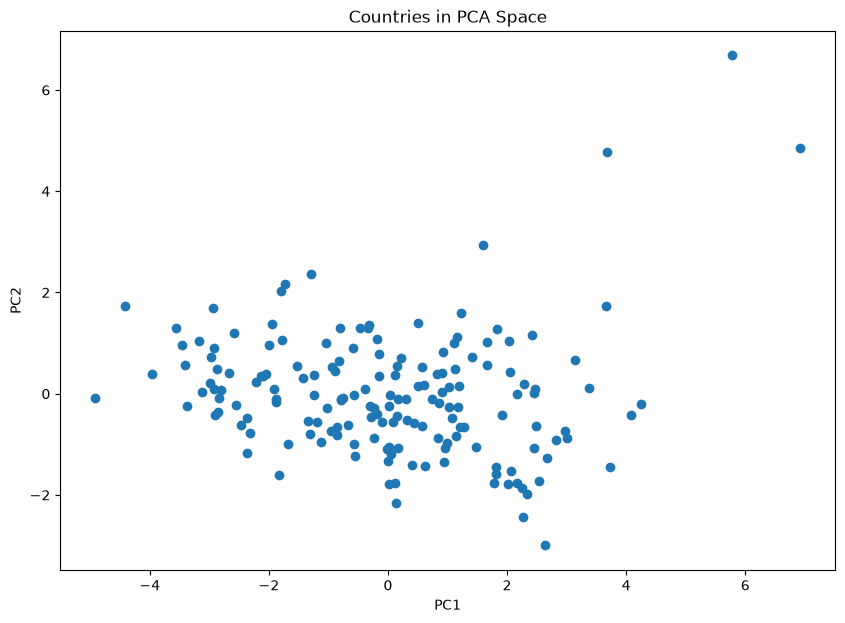

In [54]:
# Create a 2D representation
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print(X_pca_2d.shape)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Countries in PCA Space")

plt.show()

In [119]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1","PC2"],
    index=X.columns
)

print(loadings)

                 PC1       PC2
child_mort -0.419519  0.192884
exports     0.283897  0.613163
health      0.150838 -0.243087
imports     0.161482  0.671821
income      0.398441  0.022536
inflation  -0.193173 -0.008404
life_expec  0.425839 -0.222707
total_fer  -0.403729  0.155233
gdpp        0.392645 -0.046022


<built-in function bincount>
<built-in function bincount>
<built-in function bincount>


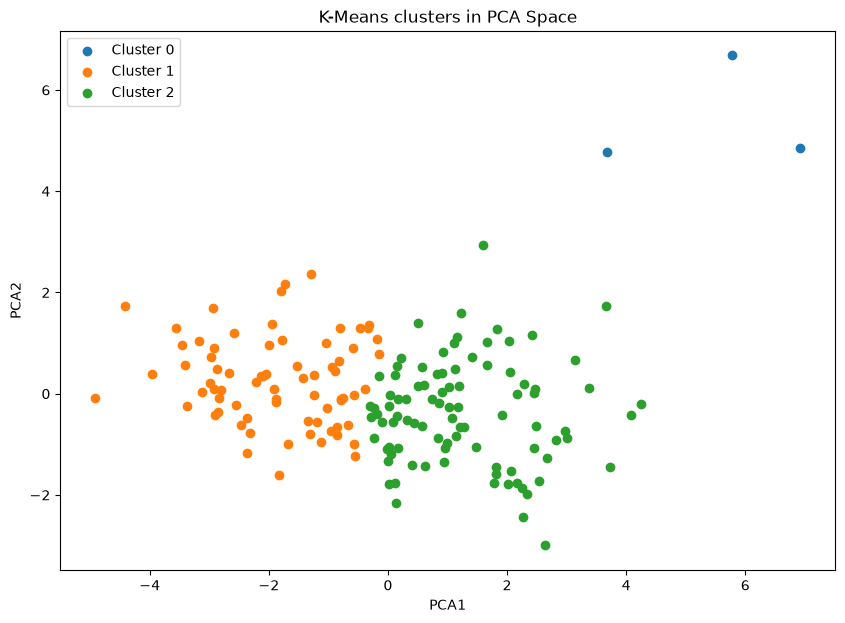

In [55]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

label_pca = model.fit_predict(X_pca)

plt.figure(figsize=(10, 7))

for cluster in np.unique(label_pca):
    mask = label_pca == cluster
    
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster}"
    )
    print(np.bincount)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("K-Means clusters in PCA Space")
plt.legend()

plt.show()

In [56]:
model_original = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_original = model_original.fit_predict(X_scaled)

score_original = silhouette_score(
    X_scaled,
    labels_original
)

print("Original: ", score_original)

model_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_pca = model_pca.fit_predict(X_pca)

score_pca = silhouette_score(
    X_pca,
    labels_pca
)

print("PCA: ", score_pca)

Original:  0.28329575683463126
PCA:  0.4416299354904196


In [57]:
# A Better PCA approach for clustering
pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)
print(pca.n_components_)

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = model.fit_predict(X_pca)

(167, 5)
5


Original Dimensions:  9
PCA Dimensions:  5
Original Dimensions:  0.9453099756439515

Siloutte scores
------------------------------

Without PCA:  0.28329575683463126

With PCA:  0.3079769786519013


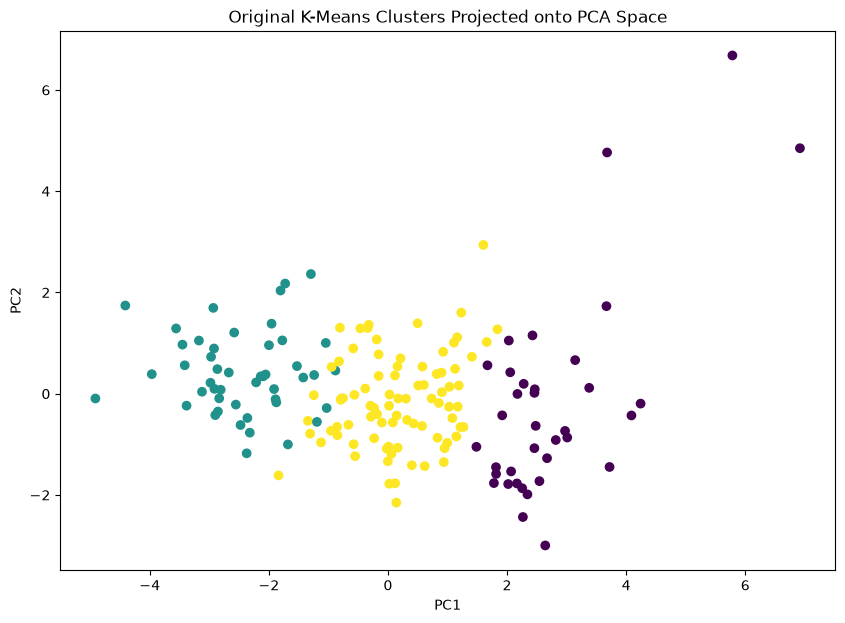

In [58]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Scale

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means without PCA
kmeans_original = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)


labels_original = kmeans_original.fit_predict(X_scaled)

original_score = silhouette_score(
    X_scaled,
    labels_original
)

# PCA
pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X_scaled)

print("Original Dimensions: ", X_scaled.shape[1])
print("PCA Dimensions: ", X_pca.shape[1])
print("Original Dimensions: ", pca.explained_variance_ratio_.sum())

# K-Means after PCA
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_pca = kmeans_pca.fit_predict(X_pca)
score_pca = silhouette_score(
    X_pca,
    labels_pca
)

print("\nSiloutte scores")
print("-"*30)
print("\nWithout PCA: ", score_original)
print("\nWith PCA: ", score_pca)

pca_visual = PCA(n_components=2)

X_visual = pca_visual.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=labels_original
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Original K-Means Clusters Projected onto PCA Space")
plt.show()

### Hierarchical Clustering
So far, K-Means has required us to decide before clustering<br>
`K = ?`<br>
Heirarchical clustering gives us a different way to think about the problem:<br>
**Instead of immediately deciding how many groups exists, Let's build a hierarchy of which observations are most similar to each other.**

#### Agglomerative clustering
Agglomerative -> Bottom -> up<br>
Divisive -> top -> down

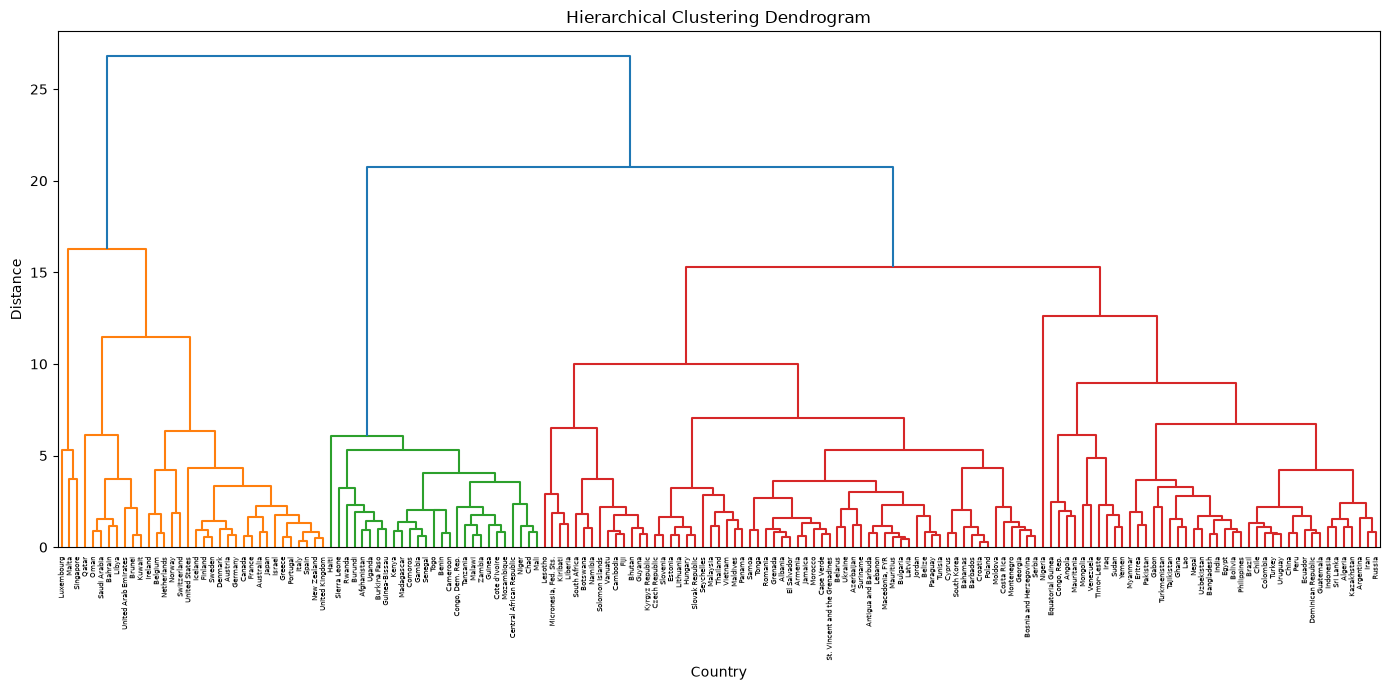

In [59]:
# Build a Dendrogram

from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(
    X_scaled,
    method="ward"
)

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    labels=df["country"].values,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Country")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

In [60]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels_hierarchical = model.fit_predict(X_scaled)
print(labels_hierarchical)
print(np.bincount(labels_hierarchical))

[2 1 1 1 1 1 1 0 0 1 1 0 1 1 1 0 1 2 1 1 1 1 1 0 1 2 2 1 2 0 1 2 2 1 1 1 2
 2 1 1 2 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1 2 1 0 1 0 1 1 2 2 1 2 1 0 1 1 1 1 0
 0 0 1 0 1 1 2 1 0 1 1 1 1 1 1 0 1 0 1 2 2 1 1 2 0 1 1 1 1 1 1 1 2 1 1 1 0
 0 2 1 0 0 1 1 1 1 1 1 0 0 1 1 2 1 0 2 1 1 2 0 1 1 1 1 1 0 1 1 1 1 0 0 1 2
 1 1 2 1 1 1 1 2 1 0 0 0 1 1 1 1 1 1 2]
[ 34 106  27]


In [61]:
# Compare with KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)
print(labels_kmeans)
print(np.bincount(labels_kmeans))

[1 2 2 1 2 2 2 0 0 2 2 0 2 2 2 0 2 1 2 2 2 1 2 0 2 1 1 2 1 0 2 1 1 2 2 2 1
 1 1 2 1 2 0 0 0 2 2 2 2 1 1 2 2 0 0 1 1 2 0 1 0 2 2 1 1 2 1 2 0 2 2 2 1 0
 0 0 2 0 2 2 1 1 0 2 1 2 2 1 1 2 2 0 2 1 1 2 2 1 0 1 2 2 2 2 2 2 1 2 1 2 0
 0 1 1 0 2 1 2 2 2 2 2 0 0 2 2 1 2 2 1 2 2 1 0 0 0 2 1 0 0 2 2 1 2 0 0 2 1
 2 1 1 2 2 2 2 1 2 0 0 0 2 2 2 2 2 1 1]
[36 47 84]


#### Evaluate hierarchical clustering

In [62]:
from sklearn.metrics import silhouette_score

score_hierarchical = silhouette_score(
    X_scaled,
    labels_hierarchical
)

score_kmeans = silhouette_score(
    X_scaled,
    labels_kmeans
)

print("K-Means: ",score_kmeans)
print("Hierarchical: ",score_hierarchical)

K-Means:  0.28329575683463126
Hierarchical:  0.24563001303300652


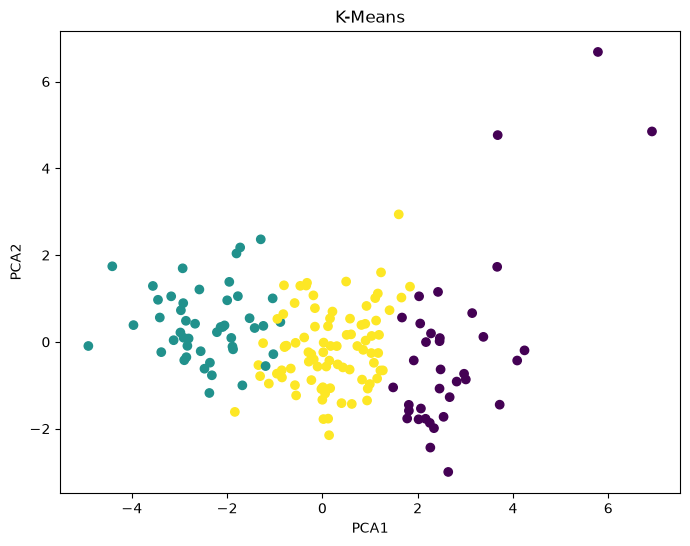

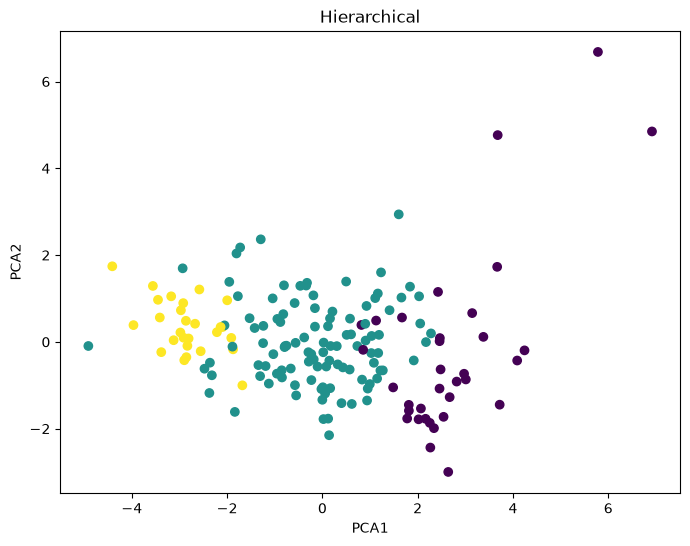

In [63]:
pca = PCA(n_components=2)
X_visual = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=labels_kmeans
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("K-Means")

plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=labels_hierarchical
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Hierarchical")

plt.show()

In [64]:
# Linkage Experiment
methods = [
    "single",
    "complete",
    "average",
    "ward"   
]

for method in methods:
    if method == "ward":
        mode = AgglomerativeClustering(
            n_clusters=3,
            linkage=method
        )
    else:
        model = AgglomerativeClustering(
            n_clusters=3,
            linkage=method,
            metric="euclidean"
        )
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"{method:10s} ->"
        f"{score:.3f}"
    )

single     ->0.569
complete   ->0.290
average    ->0.562
ward       ->0.562


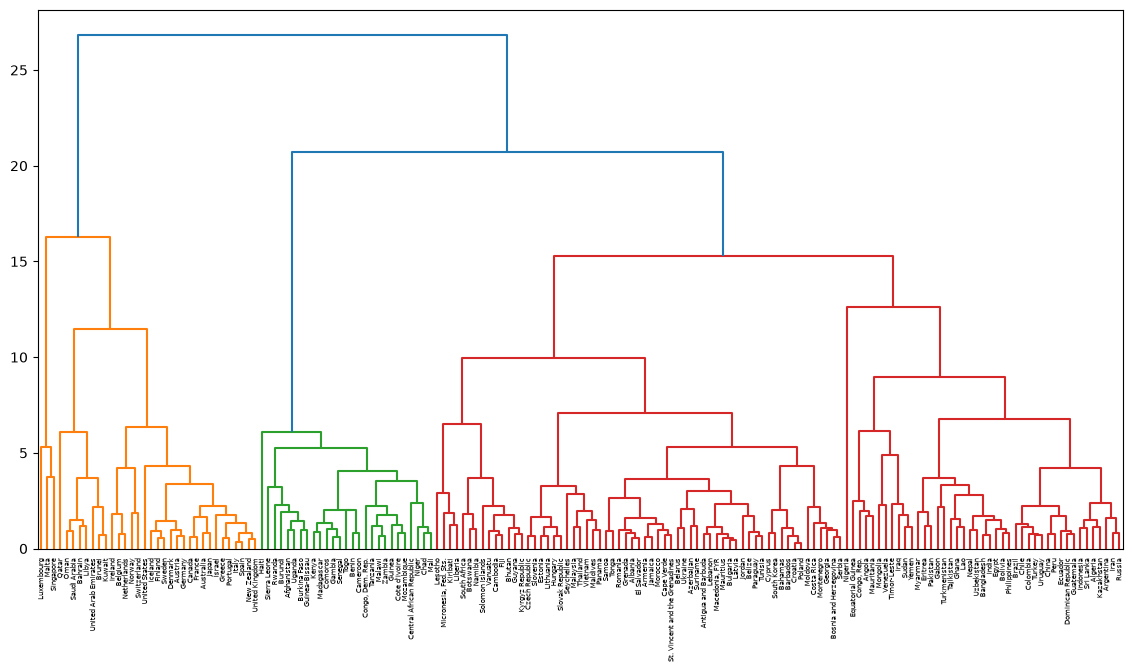

K= 2, Silhouette= 0.315, Sizes = [133  34]
K= 3, Silhouette= 0.246, Sizes = [ 34 106  27]
K= 4, Silhouette= 0.248, Sizes = [106  31  27   3]
K= 5, Silhouette= 0.219, Sizes = [43 31 27  3 63]
single     ->0.5689127494518488
complete   ->0.29005247526122313
average    ->0.5620472870560562
ward       ->0.5620472870560562


In [65]:
# Build Dendrogram
Z = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(14,7))
dendrogram(
    Z,
    labels=df["country"].values,
    leaf_rotation=90
)
plt.show()

# 2. Try different K values
for k in [2,3,4,5]:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"K= {k}, "
        f"Silhouette= {score:.3f}, "
        f"Sizes = {np.bincount(labels)}"
    )

# 3. Compare Linkage

for method in methods:
    if method == "ward":
        mode = AgglomerativeClustering(
            n_clusters=3,
            linkage=method
        )
    else:
        model = AgglomerativeClustering(
            n_clusters=3,
            linkage=method,
            metric="euclidean"
        )
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"{method:10s} ->"
        f"{silhouette_score(X_scaled, labels)}"
    )

#### DBSCAN: Density-Based Clustering
K-Means -> **"Which centroid is this point closest to?"** <br>
Hierarchical -> **"How are these points related hierachically?"** <br>
DBSCAN -> **"Is this point part of the sufficiently dense region?"**

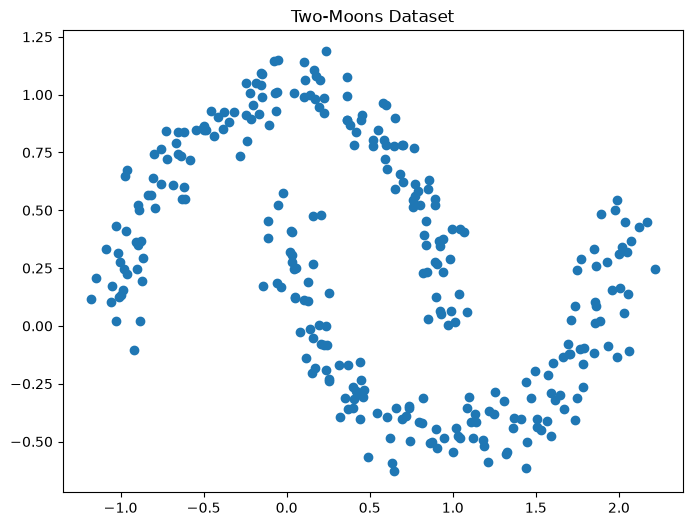

In [66]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X_moons, y_moons = make_moons(
    n_samples=300,
    noise = 0.08,
    random_state=42
)

plt.figure(figsize=(8,6))

plt.scatter(
    X_moons[:, 0],
    X_moons[:, 1]
)

plt.title("Two-Moons Dataset")
plt.show()

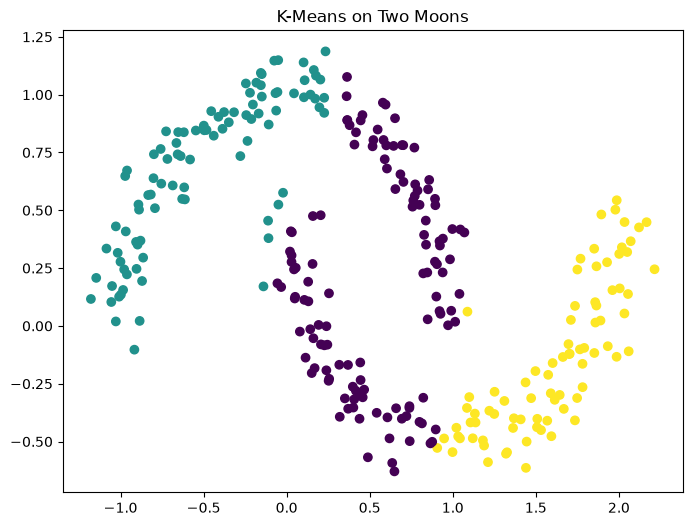

In [67]:
from sklearn.cluster import KMeans

kmeas = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_moons)


plt.figure(figsize=(8, 6))

plt.scatter(
    X_moons[:, 0],
    X_moons[:, 1],
    c=labels_kmeans
)

plt.title("K-Means on Two Moons")
plt.show()

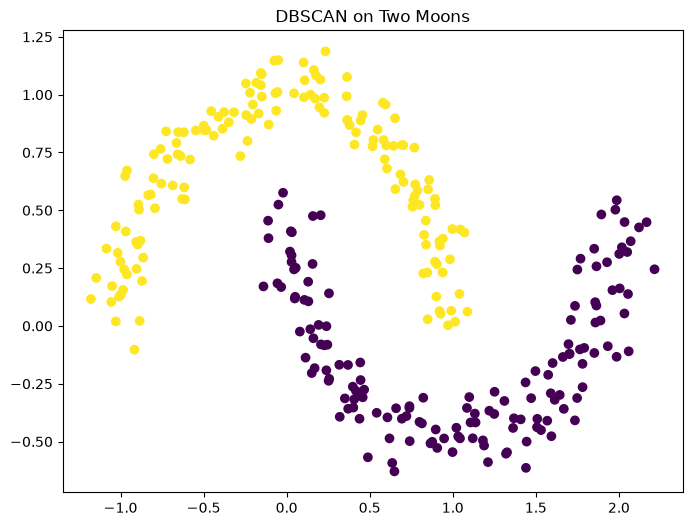

In [68]:
# Now DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_moons)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_moons[:, 0],
    X_moons[:, 1],
    c=labels_dbscan
)

plt.title("DBSCAN on Two Moons")
plt.show()

In [69]:
print(np.unique(labels_dbscan))

noise_count = np.sum(labels_dbscan==-1)

print("Noice points: ", noise_count)

[0 1]
Noice points:  0


In [70]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(
    X_scaled
)

print(np.unique(labels_dbscan))

[-1  0]


In [71]:
# eps is extremely important

for eps in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = model.fit_predict(X_scaled)

    n_clusters = len(
        set(labels) - {-1}
    )

    n_noise = np.sum(
        labels == -1
    )

    print(
        f"eps = {eps:.2f} | "
        f"cluster = {n_clusters} | "
        f"noise = {n_noise}"
    )

eps = 0.50 | cluster = 0 | noise = 167
eps = 0.75 | cluster = 2 | noise = 155
eps = 1.00 | cluster = 3 | noise = 94
eps = 1.25 | cluster = 3 | noise = 49
eps = 1.50 | cluster = 1 | noise = 30
eps = 2.00 | cluster = 1 | noise = 15


In [72]:
# min_samples
for min_samples in [3,5,10,15]:
    model = DBSCAN(
        eps=1.0,
        min_samples=min_samples
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels) - {-1})

    n_noise = np.sum(labels==-1)

    print(
        f"min_samples = {min_samples} | "
        f"cluster = {n_clusters} | "
        f"noise = {n_noise}"
    )

min_samples = 3 | cluster = 6 | noise = 72
min_samples = 5 | cluster = 3 | noise = 94
min_samples = 10 | cluster = 1 | noise = 152
min_samples = 15 | cluster = 0 | noise = 167


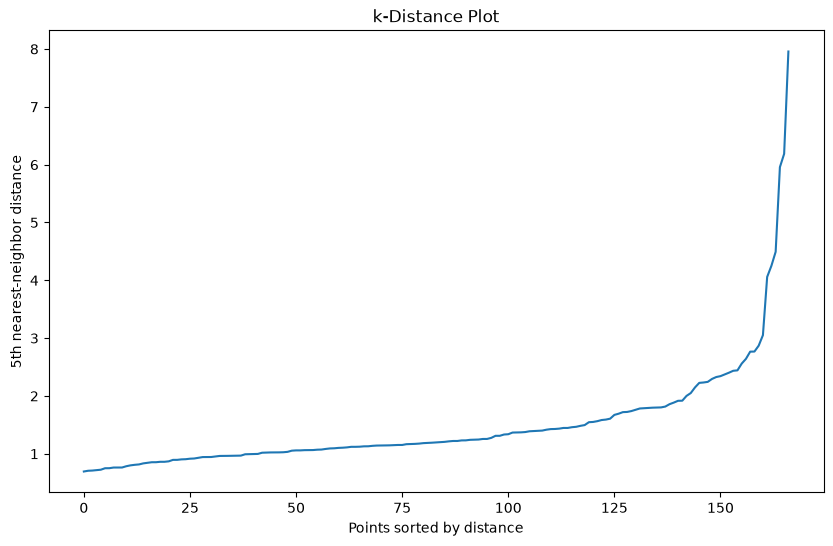

In [73]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.xlabel("Points sorted by distance")
plt.ylabel("5th nearest-neighbor distance")
plt.title("k-Distance Plot")

plt.show()

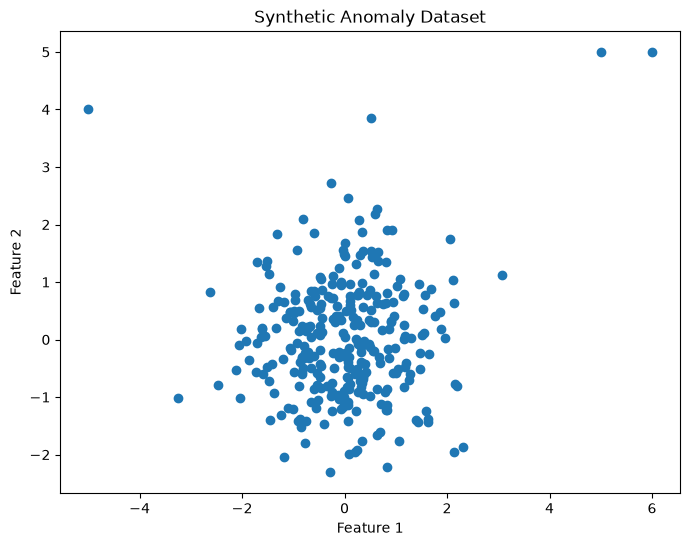

In [74]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

normal_data = np.random.normal(
    loc=0,
    scale=1,
    size=(300,2)
)

anomalies = np.array([
    [5,5],
    [6,5],
    [-5,4]
])

X_anomalies = np.vstack([
    normal_data,
    anomalies
])

plt.figure(figsize=(8,6))

plt.scatter(
    X_anomalies[:, 0],
    X_anomalies[:, 1]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Anomaly Dataset")

plt.show()

In [75]:
# Run Isolation Forest

from sklearn.ensemble import IsolationForest

for contamination in [0.01, 0.03, 0.05, 0.10]:
    
    model = IsolationForest(
        random_state=42,
        contamination=contamination
    )
    
    model.fit(X_anomalies)
    
    predictions = model.fit_predict(X_anomalies)

    n_anomalies = np.sum(
        predictions == -1
    )

    print(
        f"contamination = {contamination} "
        f"-> anomalies = {n_anomalies} "
    )

scores = model.decision_function(X_anomalies)
print(scores[:10])

contamination = 0.01 -> anomalies = 4 
contamination = 0.03 -> anomalies = 10 
contamination = 0.05 -> anomalies = 16 
contamination = 0.1 -> anomalies = 31 
[0.12391178 0.07889347 0.13469183 0.07092586 0.13370118 0.1344568
 0.00086098 0.05952903 0.10659612 0.06023657]


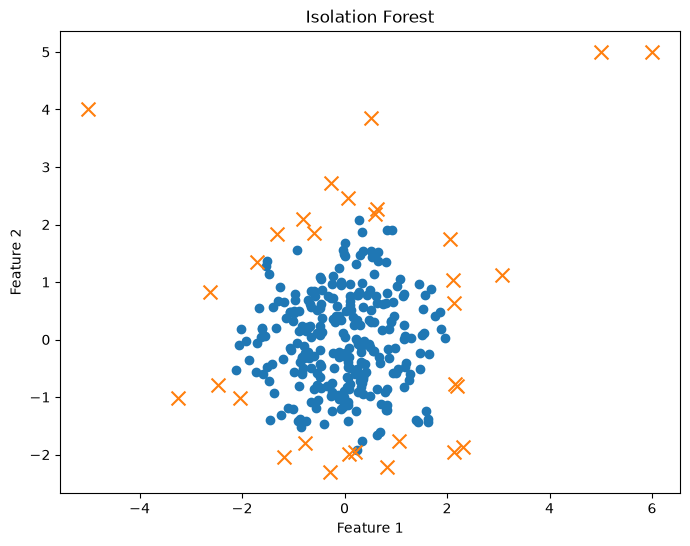

In [76]:
normal_mask = predictions == 1
anomaly_mask = predictions == -1

plt.figure(figsize=(8,6))

plt.scatter(
    X_anomalies[normal_mask, 0],
    X_anomalies[normal_mask, 1]
)

plt.scatter(
    X_anomalies[anomaly_mask, 0],
    X_anomalies[anomaly_mask, 1],
    marker="x",
    s=100
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Isolation Forest")

plt.show()

In [86]:
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

country_predictions = iso_forest.fit_predict(
    X_scaled
)

country_results = df.copy()
scores = iso_forest.decision_function(X_scaled)

country_results["anomaly"] = (country_predictions == -1)
country_results["normal"] = (country_predictions == 1)
country_results["score"] = scores

print(
    country_results
    .sort_values("score")
    .head(15)
     )

# country_results[
#     country_results["anomaly"]
# ]

# country_results[
#     country_results["normal"]
# ]

                      country  child_mort  exports  ...  anomaly  normal     score
91                 Luxembourg         2.8    175.0  ...     True   False -0.130109
133                 Singapore         2.8    200.0  ...     True   False -0.127879
66                      Haiti       208.0     15.3  ...     True   False -0.110310
113                   Nigeria       130.0     25.3  ...     True   False -0.075544
49          Equatorial Guinea       111.0     85.8  ...     True   False -0.073583
123                     Qatar         9.0     62.3  ...     True   False -0.070628
159             United States         7.3     12.4  ...     True   False -0.031578
98                      Malta         6.8    153.0  ...     True   False -0.023269
132              Sierra Leone       160.0     16.8  ...     True   False -0.000278
31   Central African Republic       149.0     11.8  ...    False    True  0.000648
87                    Lesotho        99.7     39.4  ...    False    True  0.003404
131 